# Étape 11 — Classification des nœuds CV et Jobs

La **classification supervisée** apprend une relation entre une matrice de features $X$ et une cible
$y$. Chaque ligne de $X$ décrit un nœud ; $y$ contient sa classe. Nous traitons cinq tâches locales :
séniorité CV, proxy de spécialisation CV, séniorité Job, industrie Job et proxy de spécialisation Job.
Nous comparons Dummy, Logistic Regression et Random Forest, puis une propagation relationnelle
semi-supervisée sur les 12 500 nœuds.

Les résultats sur le graphe original constituent la référence principale. Le graphe enrichi est
exploratoire, car ses arêtes ont été choisies en partie à partir de textes Step 7 contenant des
informations liées à seniority/industry. Aucun GNN n'est utilisé.

## 1. Imports et ressources Step 10

Les tables tabulaires, embeddings classification-safe et targets sont chargés séparément. Nous
contrôlons les mappings ID→ligne avant toute expérience : un embedding associé au mauvais nœud
produirait une fuite ou des résultats incohérents. Le manifest confirme aussi que les embeddings
Step 7 sont interdits pour la classification directe.

In [1]:
from pathlib import Path
import json,pickle,time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,f1_score,
 precision_score,recall_score,confusion_matrix,ConfusionMatrixDisplay)
from IPython.display import display

SEED=42
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
RESULTS=ROOT/'results'; DATA=ROOT/'data'/'processed'; FIGURES=ROOT/'figures'/'step11'
FIGURES.mkdir(parents=True,exist_ok=True)
start_time=time.perf_counter()

resume_original=pd.read_csv(RESULTS/'step10_resume_features_original.csv',dtype={'resume_id':str})
resume_enriched=pd.read_csv(RESULTS/'step10_resume_features_enriched.csv',dtype={'resume_id':str})
resume_targets=pd.read_csv(RESULTS/'step10_resume_targets.csv',dtype={'resume_id':str})
job_original=pd.read_csv(RESULTS/'step10_job_features_original.csv',dtype={'job_id':str})
job_enriched=pd.read_csv(RESULTS/'step10_job_features_enriched.csv',dtype={'job_id':str})
job_targets=pd.read_csv(RESULTS/'step10_job_targets.csv',dtype={'job_id':str})
resume_embeddings=np.load(DATA/'resume_classification_embeddings.npy')
job_embeddings=np.load(DATA/'job_classification_embeddings.npy')
resume_map=pd.read_csv(DATA/'resume_classification_embedding_ids.csv',dtype={'resume_id':str})
job_map=pd.read_csv(DATA/'job_classification_embedding_ids.csv',dtype={'job_id':str})
manifest=json.loads((RESULTS/'step10_feature_manifest.json').read_text(encoding='utf-8'))
skill_map_df=pd.read_csv(RESULTS/'step5_skill_communities.csv')
with (DATA/'cv_job_graph.pkl').open('rb') as f:G_original=pickle.load(f)
with (DATA/'cv_job_graph_enriched.pkl').open('rb') as f:G_enriched=pickle.load(f)

assert resume_original.resume_id.tolist()==resume_enriched.resume_id.tolist()==resume_map.resume_id.tolist()
assert job_original.job_id.tolist()==job_enriched.job_id.tolist()==job_map.job_id.tolist()
assert resume_embeddings.shape==(10_000,384) and job_embeddings.shape==(2_500,384)
assert any(x.get('unsafe_for_direct_target_classification') for x in manifest['embedding_artifacts'] if x['name']=='resume_embeddings.npy')
print('Ressources alignées :',resume_original.shape,job_original.shape)

Ressources alignées : (10000, 15) (2500, 8)


## 2. Cibles réelles et pseudo-labels de spécialisation

Les séniorités et industries sont des labels du dataset. La spécialisation n'a pas de vérité terrain
humaine : nous créons un **proxy** transparent. Un nœud est `specialized` si ses skills obligatoires
appartiennent à exactement une communauté, sinon `generalist` s'il en couvre plusieurs.

Pour les CV, `n_skill_communities` fournit ce nombre. Pour les Jobs, nous projetons uniquement
`must_have_skills` via le mapping Step 5. Un Job à zéro communauté déclencherait une erreur. Ces
pseudo-labels sont sauvegardés avec leur définition et ne seront jamais présentés comme vérité
humaine.

In [2]:
cv_spec=pd.DataFrame({'node_id':resume_original.resume_id,'node_type':'CV'})
cv_counts=resume_original.set_index('resume_id').loc[cv_spec.node_id,'n_skill_communities'].to_numpy()
assert (cv_counts>=1).all()
cv_spec['specialization_label']=np.where(cv_counts==1,'specialized','generalist')

skill_to_community=dict(zip(skill_map_df.skill,skill_map_df.skill_community))
job_counts=[]
for job in job_original.job_id:
    skills=G_original.nodes[job].get('must_have_skills',[])
    missing=[s for s in skills if s not in skill_to_community]
    assert not missing, f'Skills sans communauté pour {job}: {missing}'
    job_counts.append(len({skill_to_community[s] for s in skills}))
assert min(job_counts)>=1
job_spec=pd.DataFrame({'node_id':job_original.job_id,'node_type':'Job'})
job_spec['specialization_label']=np.where(np.array(job_counts)==1,'specialized','generalist')
definition='specialized if exactly one skill community; generalist if more than one'
specialization_targets=pd.concat([cv_spec,job_spec],ignore_index=True)
specialization_targets['label_definition']=definition
specialization_targets.to_csv(RESULTS/'step11_specialization_targets.csv',index=False)

local_targets={
 'CV seniority':resume_targets.set_index('resume_id').seniority,
 'CV specialization proxy':cv_spec.set_index('node_id').specialization_label,
 'Job seniority':job_targets.set_index('job_id').seniority,
 'Job industry':job_targets.set_index('job_id').industry,
 'Job specialization proxy':job_spec.set_index('node_id').specialization_label,
}

## 3. Distribution des classes et métriques

Accuracy est la proportion totale correcte, mais peut masquer une classe minoritaire. Le
**macro-F1** calcule F1 par classe puis leur moyenne non pondérée : chaque classe compte autant.
Nous en faisons la métrique principale. Balanced accuracy moyenne les recalls par classe ; weighted-F1
pondère au contraire selon les effectifs. Les matrices de confusion montrent les erreurs classe par
classe.

,task,label,count,proportion,n_examples,n_classes
0,CV seniority,Junior,3372,0.3372,10000,3
1,CV seniority,Mid,3365,0.3365,10000,3
2,CV seniority,Senior,3263,0.3263,10000,3
3,CV specialization proxy,specialized,6841,0.6841,10000,2
4,CV specialization proxy,generalist,3159,0.3159,10000,2
5,Job seniority,Junior,855,0.3420,2500,3
6,Job seniority,Mid,825,0.3300,2500,3
7,Job seniority,Senior,820,0.3280,2500,3
8,Job industry,Healthcare,290,0.1160,2500,10
9,Job industry,FinTech,279,0.1116,2500,10


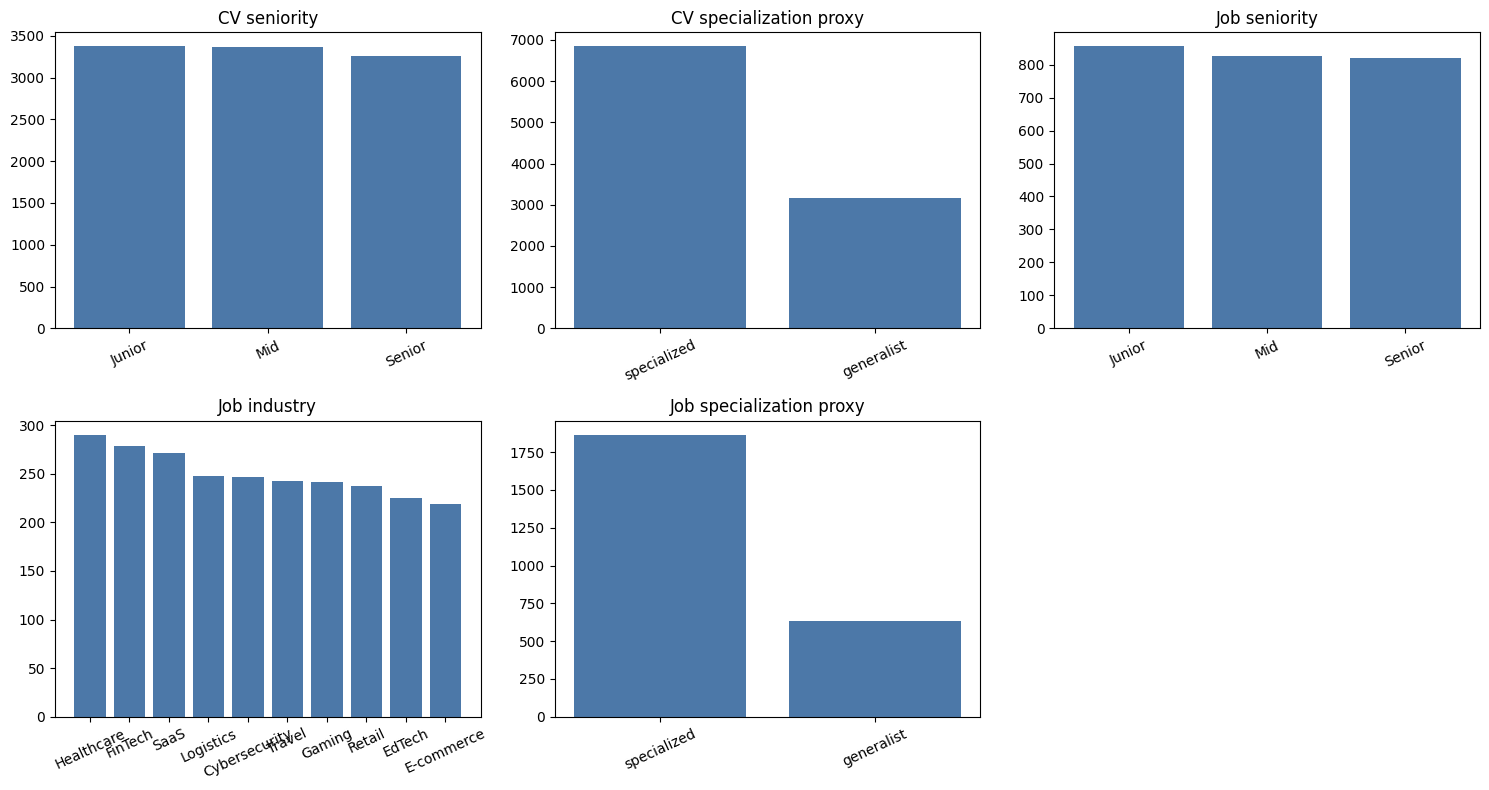

In [3]:
distribution_rows=[]
for task,y in local_targets.items():
    counts=y.value_counts()
    for label,count in counts.items():
        distribution_rows.append({'task':task,'label':label,'count':int(count),'proportion':float(count/len(y)),
                                  'n_examples':len(y),'n_classes':counts.size})
class_distributions=pd.DataFrame(distribution_rows)
display(class_distributions)

tasks=list(local_targets)
fig,axes=plt.subplots(2,3,figsize=(15,8)); axes=axes.ravel()
for ax,task in zip(axes,tasks):
    x=class_distributions[class_distributions.task==task]
    ax.bar(x.label,x['count'],color='#4C78A8'); ax.set_title(task); ax.tick_params(axis='x',rotation=25)
axes[-1].axis('off'); fig.tight_layout(); fig.savefig(FIGURES/'class_distributions.png',dpi=170,bbox_inches='tight'); plt.show()

## 4. Splits 70/15/15 stratifiés et reproductibles

Le train ajuste preprocessing et modèles ; validation choisit la configuration ; test ne sert qu'à
l'évaluation finale. La **stratification** conserve approximativement les proportions de classes.
Avec seed 42, nous divisons d'abord 70/30, puis partageons les 30 % en validation/test égaux.

Les IDs — et non seulement les positions — sont sauvegardés. Original et enrichi utilisent exactement
les mêmes IDs pour qu'une différence provienne uniquement de la version du graphe.

In [4]:
def stratified_split(ids,y):
    train_ids,temp_ids=train_test_split(np.asarray(ids),test_size=.30,random_state=SEED,stratify=np.asarray(y))
    y_by_id=dict(zip(ids,y)); temp_y=[y_by_id[x] for x in temp_ids]
    val_ids,test_ids=train_test_split(temp_ids,test_size=.50,random_state=SEED,stratify=temp_y)
    return {'train':train_ids.tolist(),'validation':val_ids.tolist(),'test':test_ids.tolist()}

splits={task:stratified_split(y.index.tolist(),y.tolist()) for task,y in local_targets.items()}
(RESULTS/'step11_classification_splits.json').write_text(json.dumps(splits,indent=2,ensure_ascii=False),encoding='utf-8')
print({task:{k:len(v) for k,v in sp.items()} for task,sp in splits.items()})

{'CV seniority': {'train': 7000, 'validation': 1500, 'test': 1500}, 'CV specialization proxy': {'train': 7000, 'validation': 1500, 'test': 1500}, 'Job seniority': {'train': 1750, 'validation': 375, 'test': 375}, 'Job industry': {'train': 1750, 'validation': 375, 'test': 375}, 'Job specialization proxy': {'train': 1750, 'validation': 375, 'test': 375}}


## 5. Familles de features et règle anti-circularité

Les features structurelles décrivent la position globale ; les embeddings safe décrivent le texte ;
les communautés internes décrivent la diversité des skills. `community_global` et
`dominant_skill_community` sont catégorielles, jamais ordinales.

Pour la spécialisation, le label vient des skills. Réutiliser nombre de skills, entropie, communauté
dominante ou embedding contenant les skills donnerait la règle de construction au modèle. Nous
interdisons donc toute feature dérivée du texte/skills et utilisons uniquement la structure globale.
La question devient : « la position dans le graphe permet-elle de retrouver ce proxy défini ailleurs ? »

In [5]:
STRUCT=['degree','bipartite_degree_centrality','pagerank','is_isolate','component_size','community_size','community_global']
INTERNAL=['n_skills','n_skill_communities','dominant_skill_community','dominant_skill_community_count',
          'dominant_skill_community_share','skill_community_entropy','skill_community_entropy_normalized']
SPECIALIZATION_FORBIDDEN=set(INTERNAL+['skills','semantic_embedding'])

def embedding_frame(ids,embeddings,prefix='emb'):
    return pd.DataFrame(embeddings,index=ids,columns=[f'{prefix}_{i}' for i in range(embeddings.shape[1])])
resume_emb_df=embedding_frame(resume_map.resume_id,resume_embeddings)
job_emb_df=embedding_frame(job_map.job_id,job_embeddings)

def feature_configs(task):
    is_cv=task.startswith('CV'); is_spec='specialization' in task
    orig=(resume_original if is_cv else job_original).set_index('resume_id' if is_cv else 'job_id')
    enr=(resume_enriched if is_cv else job_enriched).set_index('resume_id' if is_cv else 'job_id')
    emb=resume_emb_df if is_cv else job_emb_df
    configs=[]
    for version,frame in [('original',orig),('enriched',enr)]: configs.append(('STRUCTURAL',version,frame[STRUCT].copy(),['community_global']))
    if is_spec: return configs
    configs.append(('SEMANTIC','invariant',emb.copy(),[]))
    if is_cv:
        configs.append(('INTERNAL_SKILLS','invariant',orig[INTERNAL].copy(),['dominant_skill_community']))
        for version,frame in [('original',orig),('enriched',enr)]:
            configs.append(('ALL_SAFE',version,frame[STRUCT+INTERNAL].join(emb),['community_global','dominant_skill_community']))
    else:
        for version,frame in [('original',orig),('enriched',enr)]:
            configs.append(('ALL_SAFE',version,frame[STRUCT].join(emb),['community_global']))
    return configs

## 6. Preprocessing et modèles classiques

Logistic Regression apprend des frontières linéaires probabilistes ; elle bénéficie d'un
`StandardScaler`. Random Forest agrège 300 arbres non linéaires et peut capturer des interactions.
Dummy prédit toujours la classe majoritaire et mesure le niveau sans information utile.

Le `ColumnTransformer` est inclus dans chaque pipeline : scaler et OneHotEncoder sont donc ajustés
uniquement lors de `fit(train)`. `handle_unknown='ignore'` évite une erreur si une communauté apparaît
seulement en validation/test. Aucune PCA n'est nécessaire pour 384 dimensions. Paramètres fixes :
aucune recherche sur test.

In [6]:
MODEL_ORDER={'Dummy':0,'Logistic Regression':1,'Random Forest':2}
def make_pipeline(model_name,numeric,categorical):
    if model_name=='Random Forest': numeric_transform='passthrough'
    else: numeric_transform=StandardScaler(with_mean=False)
    prep=ColumnTransformer([('num',numeric_transform,numeric),
                            ('cat',OneHotEncoder(handle_unknown='ignore'),categorical)],remainder='drop')
    if model_name=='Dummy': model=DummyClassifier(strategy='most_frequent')
    elif model_name=='Logistic Regression': model=LogisticRegression(C=1.0,max_iter=3000,class_weight='balanced',random_state=SEED)
    else: model=RandomForestClassifier(n_estimators=300,min_samples_leaf=2,class_weight='balanced_subsample',random_state=SEED,n_jobs=-1)
    return Pipeline([('preprocess',prep),('model',model)])

def metrics(y_true,pred):
    return {'accuracy':accuracy_score(y_true,pred),'balanced_accuracy':balanced_accuracy_score(y_true,pred),
            'macro_f1':f1_score(y_true,pred,average='macro',zero_division=0),
            'weighted_f1':f1_score(y_true,pred,average='weighted',zero_division=0),
            'precision_macro':precision_score(y_true,pred,average='macro',zero_division=0),
            'recall_macro':recall_score(y_true,pred,average='macro',zero_division=0)}

## 7. Entraînement, sélection validation et test final

Pour chaque tâche/famille/version, les trois modèles sont ajustés sur train puis comparés sur
validation. La règle est : macro-F1 maximal, puis balanced accuracy, puis modèle le plus simple
(Dummy < Logistic < Random Forest). Seul le gagnant de chaque configuration est ensuite appliqué au
test. Les objets ajustés sont gardés en mémoire ; le test ne provoque aucun réentraînement.

In [7]:
results_rows=[]; selected_objects={}; selected_predictions={}; importance_rows=[]
for task,y_series in local_targets.items():
    sp=splits[task]; y_map=y_series.to_dict()
    for family,version,X,categorical in feature_configs(task):
        assert set(y_series.index)==set(X.index)
        numeric=[c for c in X.columns if c not in categorical]
        fitted=[]
        for model_name in MODEL_ORDER:
            pipe=make_pipeline(model_name,numeric,categorical)
            pipe.fit(X.loc[sp['train']], [y_map[i] for i in sp['train']])
            val_pred=pipe.predict(X.loc[sp['validation']]); val_true=[y_map[i] for i in sp['validation']]
            m=metrics(val_true,val_pred)
            results_rows.append({'task':task,'method':model_name,'feature_family':family,'graph_version':version,'split':'validation',**m})
            fitted.append((model_name,pipe,m))
        model_name,pipe,val_m=sorted(fitted,key=lambda z:(-z[2]['macro_f1'],-z[2]['balanced_accuracy'],MODEL_ORDER[z[0]]))[0]
        test_true=[y_map[i] for i in sp['test']]; test_pred=pipe.predict(X.loc[sp['test']]); test_m=metrics(test_true,test_pred)
        results_rows.append({'task':task,'method':model_name,'feature_family':family,'graph_version':version,'split':'test',**test_m})
        key=(task,family,version); selected_objects[key]=(model_name,pipe,val_m,test_m)
        selected_predictions[key]=(test_true,test_pred)
        if model_name=='Random Forest' and family!='SEMANTIC':
            names=pipe.named_steps['preprocess'].get_feature_names_out()
            values=pipe.named_steps['model'].feature_importances_
            for rank in np.argsort(values)[::-1][:15]: importance_rows.append({'task':task,'feature_family':family,'graph_version':version,'feature':names[rank],'importance':values[rank]})

classification_results=pd.DataFrame(results_rows)
pd.DataFrame(importance_rows).to_csv(RESULTS/'step11_feature_importances.csv',index=False)
print('Fits terminés :',len(classification_results.query("split=='validation'")),'; évaluations test sélectionnées :',len(classification_results.query("split=='test'")))

Fits terminés : 60 ; évaluations test sélectionnées : 20


## 8. Classifieur relationnel probabiliste

Cette méthode semi-supervisée contraste avec les modèles locaux : elle n'utilise aucune feature
individuelle. Les nœuds train ont un vecteur one-hot fixé ; les autres commencent uniformes. À chaque
itération, un nœud non labellisé reçoit la moyenne des probabilités de ses voisins. Les labels train
restent bloqués jusqu'à convergence (`tol=1e-6`, 100 itérations).

Nous propageons trois cibles disponibles sur les deux partitions : seniority, industry et proxy de
spécialisation. Les isolés ne reçoivent aucun signal et gardent la distribution uniforme. Original
est principal ; enrichi est exploratoire. Les mêmes splits globaux sont employés pour les deux.

In [8]:
all_nodes=sorted(G_original.nodes())
global_labels={
 'Global seniority':pd.Series({n:G_original.nodes[n]['seniority'] for n in all_nodes}),
 'Global industry':pd.Series({n:G_original.nodes[n]['industry'] for n in all_nodes}),
 'Global specialization proxy':specialization_targets.set_index('node_id').specialization_label.reindex(all_nodes),
}
relational_splits={task:stratified_split(y.index.tolist(),y.tolist()) for task,y in global_labels.items()}
splits['_relational_global']=relational_splits
(RESULTS/'step11_classification_splits.json').write_text(json.dumps(splits,indent=2,ensure_ascii=False),encoding='utf-8')

def normalized_adjacency(G,nodes):
    A=nx.to_scipy_sparse_array(G,nodelist=nodes,dtype=float,format='csr')
    degree=np.asarray(A.sum(axis=1)).ravel(); inv=np.zeros_like(degree); inv[degree>0]=1/degree[degree>0]
    return sparse.diags(inv)@A,degree

def relational_classifier(G,nodes,y,split,max_iter=100,tol=1e-6):
    encoder=LabelEncoder().fit(y.loc[nodes]); encoded=encoder.transform(y.loc[nodes])
    n,c=len(nodes),len(encoder.classes_); index={node:i for i,node in enumerate(nodes)}
    train_idx=np.array([index[x] for x in split['train']]); unlabeled=np.ones(n,dtype=bool); unlabeled[train_idx]=False
    P,degree=normalized_adjacency(G,nodes); probs=np.full((n,c),1/c,dtype=float)
    probs[train_idx]=0; probs[train_idx,encoded[train_idx]]=1
    for iteration in range(1,max_iter+1):
        new=P@probs; new[degree==0]=1/c; new[train_idx]=probs[train_idx]
        diff=float(np.max(np.abs(new[unlabeled]-probs[unlabeled]))); probs=new
        if diff<tol: break
    predictions=pd.Series(encoder.inverse_transform(probs.argmax(axis=1)),index=nodes)
    return predictions,iteration,diff,int((degree==0).sum())

relational_rows=[]
for task,y in global_labels.items():
    sp=relational_splits[task]
    for version,G in [('original',G_original),('enriched',G_enriched)]:
        pred,it,diff,n_iso=relational_classifier(G,all_nodes,y,sp)
        for split_name in ['validation','test']:
            ids=sp[split_name]
            for partition,node_type in [('CV','CV'),('Job','Job')]:
                subset=[n for n in ids if G_original.nodes[n]['node_type']==node_type]
                m=metrics(y.loc[subset],pred.loc[subset])
                relational_rows.append({'task':task.replace('Global ','')+f' ({partition})','method':'Relational probabilistic classifier',
                  'feature_family':'RELATIONAL','graph_version':version,'split':split_name,'iterations':it,'final_delta':diff,'n_isolates':n_iso,**m})
relational_results=pd.DataFrame(relational_rows)
display(relational_results.query("split=='test'").round(4))

,task,method,feature_family,graph_version,split,iterations,final_delta,n_isolates,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
2,seniority (CV),Relational probabilistic classifier,RELATIONAL,original,test,14,0.0,29,0.3300,0.3299,0.3296,0.3297,0.3307,0.3299
3,seniority (Job),Relational probabilistic classifier,RELATIONAL,original,test,14,0.0,29,0.3500,0.3486,0.3485,0.3495,0.3491,0.3486
6,seniority (CV),Relational probabilistic classifier,RELATIONAL,enriched,test,14,0.0,29,0.3327,0.3325,0.3322,0.3323,0.3331,0.3325
7,seniority (Job),Relational probabilistic classifier,RELATIONAL,enriched,test,14,0.0,29,0.3611,0.3603,0.3604,0.3608,0.3610,0.3603
10,industry (CV),Relational probabilistic classifier,RELATIONAL,original,test,14,0.0,29,0.0971,0.0975,0.0963,0.0961,0.0964,0.0975
11,industry (Job),Relational probabilistic classifier,RELATIONAL,original,test,14,0.0,29,0.0833,0.0821,0.0825,0.0845,0.0848,0.0821
14,industry (CV),Relational probabilistic classifier,RELATIONAL,enriched,test,13,0.0,29,0.1597,0.1597,0.1584,0.1587,0.1597,0.1597
15,industry (Job),Relational probabilistic classifier,RELATIONAL,enriched,test,13,0.0,29,0.2742,0.2715,0.2718,0.2766,0.2779,0.2715
18,specialization proxy (CV),Relational probabilistic classifier,RELATIONAL,original,test,16,0.0,29,0.9180,0.8893,0.9016,0.9165,0.9178,0.8893
19,specialization proxy (Job),Relational probabilistic classifier,RELATIONAL,original,test,16,0.0,29,0.9145,0.9387,0.8981,0.9178,0.8760,0.9387


## 9. Comparaison originale/enrichie

Pour chaque famille structurelle, les IDs, modèle, paramètres et features hors topologie sont
identiques. Le delta test est `enriched − original`. Une valeur positive est descriptive seulement :
les arêtes enrichies héritent d'un risque indirect de target leakage et ne constituent pas une
amélioration indépendante démontrée.

In [9]:
test_local=classification_results.query("split=='test'")
delta_rows=[]
for (task,family),group in test_local[test_local.graph_version.isin(['original','enriched'])].groupby(['task','feature_family']):
    if set(group.graph_version)=={'original','enriched'}:
        o=group.set_index('graph_version').loc['original']; e=group.set_index('graph_version').loc['enriched']
        delta_rows.append({'task':task,'feature_family':family,'original_model':o.method,'enriched_model':e.method,
                           'delta_macro_f1':e.macro_f1-o.macro_f1,'delta_accuracy':e.accuracy-o.accuracy})
original_vs_enriched=pd.DataFrame(delta_rows)
display(original_vs_enriched.round(5))

,task,feature_family,original_model,enriched_model,delta_macro_f1,delta_accuracy
0,CV seniority,ALL_SAFE,Logistic Regression,Logistic Regression,0.00000,0.00000
1,CV seniority,STRUCTURAL,Random Forest,Logistic Regression,-0.03550,-0.03333
2,CV specialization proxy,STRUCTURAL,Logistic Regression,Logistic Regression,0.00000,0.00000
3,Job industry,ALL_SAFE,Logistic Regression,Logistic Regression,0.00000,0.00000
4,Job industry,STRUCTURAL,Random Forest,Random Forest,0.06831,0.06933
5,Job seniority,ALL_SAFE,Random Forest,Random Forest,0.00692,0.00800
6,Job seniority,STRUCTURAL,Random Forest,Random Forest,0.00135,0.00267
7,Job specialization proxy,STRUCTURAL,Logistic Regression,Logistic Regression,0.00000,0.00000


## 10. Meilleures configurations principales et matrices de confusion

Pour chaque tâche locale, nous sélectionnons la meilleure configuration sur sa macro-F1 validation,
puis balanced accuracy, en excluant le graphe enrichi de la référence principale. La performance test
affichée vient du modèle déjà gelé. Les matrices de confusion utilisent ces cinq configurations.

,task,method,feature_family,graph_version,validation_macro_f1,validation_balanced_accuracy,test_macro_f1,test_accuracy,test_balanced_accuracy
0,CV seniority,Logistic Regression,SEMANTIC,invariant,0.86811,0.86864,0.87690,0.87733,0.87767
1,CV specialization proxy,Logistic Regression,STRUCTURAL,original,0.93938,0.96004,0.93933,0.94533,0.95947
2,Job seniority,Random Forest,STRUCTURAL,original,0.35536,0.35684,0.29891,0.29867,0.29932
3,Job industry,Logistic Regression,SEMANTIC,invariant,1.00000,1.00000,1.00000,1.00000,1.00000
4,Job specialization proxy,Logistic Regression,STRUCTURAL,original,0.83598,0.90357,0.89815,0.91467,0.94265


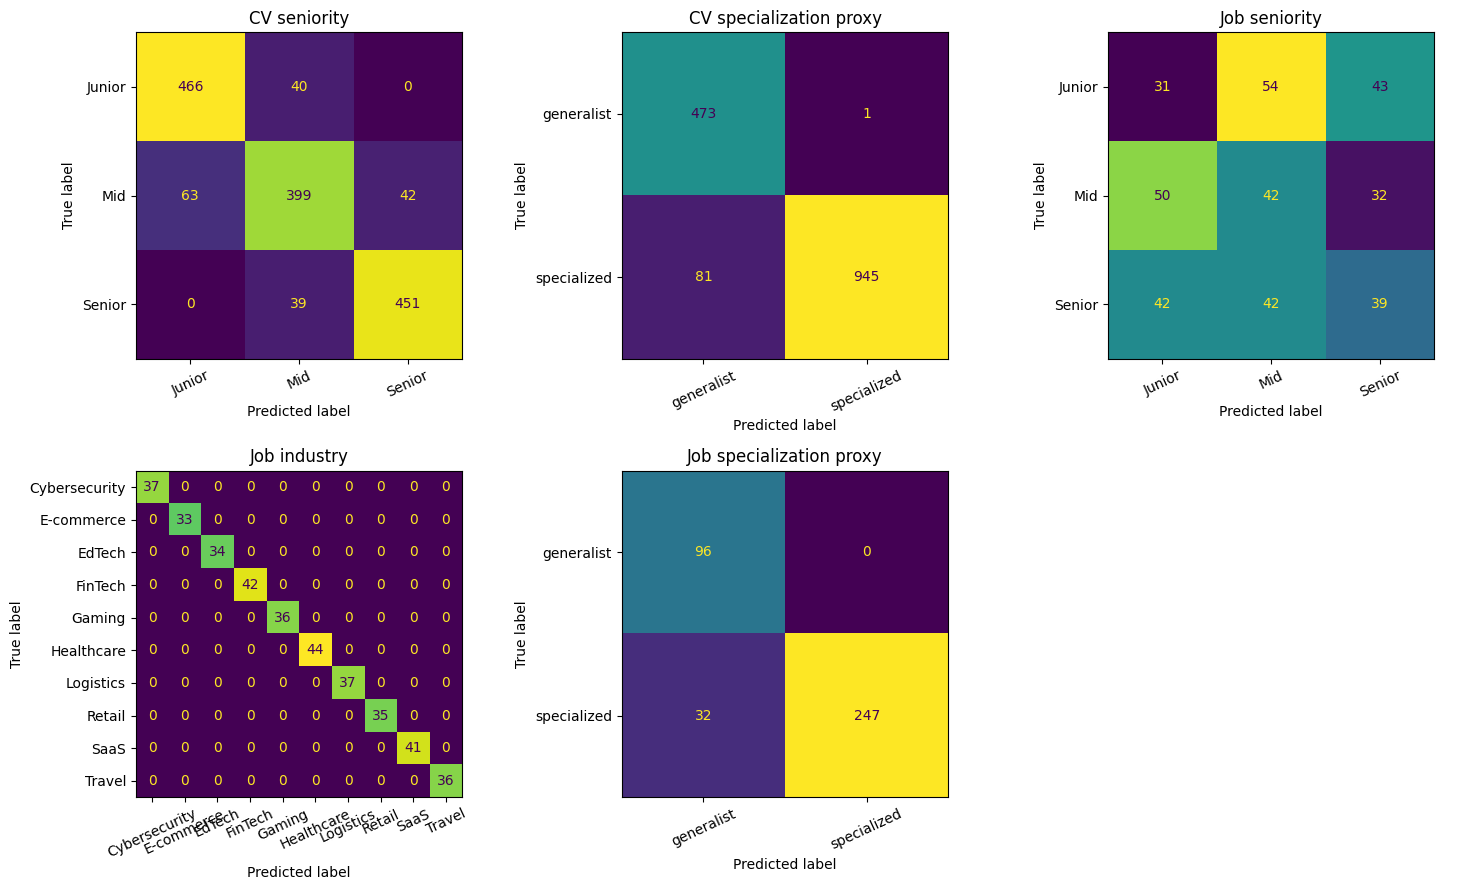

In [10]:
val_local=classification_results.query("split=='validation' and graph_version!='enriched'")
best_rows=[]; best_keys={}
for task in local_targets:
    candidates=[]
    for key,obj in selected_objects.items():
        t,f,v=key
        if t==task and v!='enriched': candidates.append((key,*obj))
    key,model_name,pipe,val_m,test_m=sorted(candidates,key=lambda z:(-z[3]['macro_f1'],-z[3]['balanced_accuracy'],MODEL_ORDER[z[1]]))[0]
    best_keys[task]=key
    best_rows.append({'task':task,'method':model_name,'feature_family':key[1],'graph_version':key[2],
                      'validation_macro_f1':val_m['macro_f1'],'validation_balanced_accuracy':val_m['balanced_accuracy'],
                      'test_macro_f1':test_m['macro_f1'],'test_accuracy':test_m['accuracy'],'test_balanced_accuracy':test_m['balanced_accuracy']})
best_models=pd.DataFrame(best_rows); best_models.to_csv(RESULTS/'step11_best_models.csv',index=False)
display(best_models.round(5))

fig,axes=plt.subplots(2,3,figsize=(15,9)); axes=axes.ravel()
for ax,task in zip(axes,local_targets):
    true,pred=selected_predictions[best_keys[task]]
    ConfusionMatrixDisplay.from_predictions(true,pred,ax=ax,colorbar=False,xticks_rotation=25)
    ax.set_title(task)
axes[-1].axis('off'); fig.tight_layout(); fig.savefig(FIGURES/'main_confusion_matrices.png',dpi=170,bbox_inches='tight'); plt.show()

## 11. Tableau commun ML local vs relationnel

Le tableau rassemble validation et test. Le relationnel exploite uniquement les corrélations de
labels entre voisins ; il ne reçoit donc pas les mêmes informations que les modèles locaux. La
comparaison illustre deux familles méthodologiques, pas une compétition feature-for-feature parfaite.

In [11]:
common_cols=['task','method','feature_family','graph_version','split','accuracy','balanced_accuracy','macro_f1','weighted_f1','precision_macro','recall_macro']
all_results=pd.concat([classification_results[common_cols],relational_results[common_cols]],ignore_index=True)
all_results.to_csv(RESULTS/'step11_classification_results.csv',index=False)
print('Résultats sauvegardés :',len(all_results),'lignes.')

Résultats sauvegardés : 104 lignes.


## 12. Limites et garde-fous

- Le dataset synthétique lie fortement rôle, skills et séniorité ; les performances peuvent être
  optimistes et ne démontrent aucune généralisation réelle.
- Les spécialisations sont des pseudo-labels construits par communautés de skills, pas des annotations
  humaines. Leurs modèles n'utilisent aucune feature de skills ou embedding sémantique.
- Les communautés sont très stables ; leur apport peut être limité ou redondant.
- Le graphe enrichi comporte un risque indirect, puisque Step 9 a exploité des textes contenant des
  cibles futures. L'original reste la référence.
- Un classifieur relationnel suppose une corrélation entre voisins ; s'il n'existe pas d'homophilie,
  sa propagation peut être faible. Les isolés gardent une distribution uniforme.

## 13. Assertions finales anti-fuite

Nous vérifions que les cibles ne figurent pas dans X, que les embeddings safe sont alignés, que les
catégories sont encodées comme telles, que la spécialisation utilise seulement la structure, que les
splits original/enrichi sont uniques, et qu'aucun PCA/GNN n'a été exécuté.

In [12]:
for task in local_targets:
    for family,version,X,categorical in feature_configs(task):
        assert 'seniority' not in X.columns and 'industry' not in X.columns and 'specialization_label' not in X.columns
        if 'specialization' in task:
            assert family=='STRUCTURAL' and not (set(X.columns)&SPECIALIZATION_FORBIDDEN)
        assert 'community_global' in categorical if 'community_global' in X.columns else True
        assert 'dominant_skill_community' in categorical if 'dominant_skill_community' in X.columns else True
assert resume_map.resume_id.tolist()==resume_original.resume_id.tolist()
assert job_map.job_id.tolist()==job_original.job_id.tolist()
assert all(len(set(sp['train'])&set(sp['validation']))==0 and len(set(sp['train'])&set(sp['test']))==0 and len(set(sp['validation'])&set(sp['test']))==0 for task,sp in splits.items() if task!='_relational_global')
assert not any('step7' in str(x).lower() for x in [resume_embeddings,job_embeddings])
assert set(best_models.graph_version)<={'original','invariant'}
print('Toutes les assertions passent : pas de PCA, pas de GNN, test jamais utilisé pour sélectionner.')

Toutes les assertions passent : pas de PCA, pas de GNN, test jamais utilisé pour sélectionner.


## 14. Résumé JSON

Le résumé conserve distributions, splits, modèles, résultats principaux, deltas et propagation
relationnelle. Il documente explicitement les contrôles de circularité et le risque enrichi.

In [13]:
summary={'seed':SEED,'class_distributions':class_distributions.to_dict(orient='records'),
 'split_sizes':{t:{k:len(v) for k,v in sp.items()} for t,sp in splits.items() if t!='_relational_global'},
 'models':{'Dummy':{'strategy':'most_frequent'},'Logistic Regression':{'C':1.0,'max_iter':3000,'class_weight':'balanced'},
           'Random Forest':{'n_estimators':300,'min_samples_leaf':2,'class_weight':'balanced_subsample'}},
 'feature_families':{'structural':STRUCT,'internal_skills':INTERNAL,'semantic_dimension':384,'all_safe':'concatenation'},
 'best_validation_configuration_per_task':best_models.to_dict(orient='records'),
 'original_vs_enriched_deltas':original_vs_enriched.to_dict(orient='records'),
 'relational_classifier_results':relational_results.to_dict(orient='records'),
 'specialization_label_definition':definition,
 'leakage_controls':{'targets_excluded_from_X':True,'step7_embeddings_used':False,'safe_embeddings_aligned':True,
  'preprocessing_fit_train_only':True,'test_used_for_selection':False,'specialization_skill_features_used':False,
  'community_ids_categorical':True,'global_PCA_fitted':False,'GNN_used':False},
 'enriched_graph_indirect_leakage_warning':True,'classification_started':True,
 'runtime_seconds':float(time.perf_counter()-start_time),'all_assertions_passed':True}
(RESULTS/'step11_node_classification_summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding='utf-8')
print('Résumé sauvegardé. Temps :',round(summary['runtime_seconds'],2),'s')

Résumé sauvegardé. Temps :

 160.61 s


## Interprétation et conclusion

- **CV seniority** : la sélection validation retient Logistic Regression avec embeddings safe
  (macro-F1 validation `0,8681`, test `0,8769`). ALL_SAFE obtient `0,8802` au test mais n'est pas
  choisi après coup. Structure seule (`0,3472`) et communautés internes seules (`0,3122`) sont
  faibles ; le signal sémantique apporte l'essentiel, les features internes ajoutent peu ici.
- **Job seniority** reste difficile : le meilleur choix validation est Random Forest structurel
  original, avec macro-F1 test `0,2989`. Semantic atteint `0,3128` et ALL_SAFE original `0,3351`
  au test, sans avoir gagné la sélection validation.
- **Job industry** est parfaitement séparée par les embeddings safe (macro-F1 test `1,0000`).
  Même sans champ direct `industry`, titres, skills et descriptions du dataset synthétique la
  révèlent fortement ; ce résultat ne garantit aucune généralisation réelle.
- La topologie seule retrouve fortement les pseudo-labels : CV specialization macro-F1 `0,9393`,
  Job specialization `0,8982`. Ce sont des proxies issus des communautés de skills, pas des
  vérités humaines, et aucune feature de skills/embedding n'a été donnée à ces modèles.
- Le relationnel est proche du hasard pour seniority (`0,3296` CV, `0,3485` Job) et industry
  (`0,0963` CV, `0,0825` Job) sur l'original, mais performant pour specialization (`0,9016` CV,
  `0,8981` Job). L'homophilie du proxy est donc bien plus forte que celle des autres labels.
- L'enrichissement a des effets locaux modestes ou ambigus : aucun changement pour les deux
  spécialisations, `+0,00135` macro-F1 structurel Job seniority, `+0,06831` pour Job industry
  structurel, mais `-0,03550` pour CV seniority structurel. Ces variations restent exploratoires
  à cause du risque indirect de fuite des arêtes Step 9.
- Tous les preprocessings ont été ajustés uniquement sur train ; validation a choisi les modèles,
  le test n'a servi qu'au rapport final. Aucun embedding Step 7, PCA ou GNN n'a été utilisé.